# Homework 2: Logistic Regression and Stochastic Gradient Descent



This assignment is due on Gradescope by **11:59pm on Thursday, April 24th**. 
Your solutions to theoretical questions should be done in Markdown and Latex directly below the associated question.
Your solutions to computational questions should include any specified Python code and results 
as well as written commentary on your conclusions.
Remember that while you can discuss the problems with your classmates, **you must write all code and solutions on your own**. Please read through the course Academic Honesty Policy [in the syllabus](https://canvas.uchicago.edu/courses/63749/assignments/syllabus).
Some problems with code may be autograded.  If we provide a function API, **do not** change it.  If we do not provide a function API, then you're free to structure your code however you like. 

**Submission instructions**: 

Please submit **two** things to the Gradescope "Homework 2" assignment: this Jupyter notebook and a PDF of this notebook. Do not compress it using tar, zip, etc.

**Name**: AGUSTÍN EYZAGUIRRE

In [92]:
# Import required packages
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
%matplotlib inline

## [100 points] Logistic Regression + SGD

In this assignment, you'll implement a Logistic Regression classifier to predict whether a reported crime (incident) results in an arrest.  We use the Chicago crime dataset used in Assignment 1, with a few modifications described below.  


Dataset has following attributes:

|Variable|Definition|Key|
|:----:|:----:|:---|
|Hour|Time of incident|integer|
|Domestic|Category of Crime|bool|
|Primary Type |Type of Crime|one hot encoded (all types with moderate arrest rate)|
|Ward	|Location of incident|one hot encoded|
|Arrest	|Whether an arrest was made|bool|




The following cell is a class to load the crime dataset.

Make sure you understand what the Dataset constructor is doing line-by-line. 

The Dataset class also uses a staticmethod. Take a minute to read about [staticmethods vs. instance methods](https://realpython.com/instance-class-and-static-methods-demystified/) in Python. Instance methods are the type you're used to. 

In [93]:
class Dataset:
    """
    Class to load dataset containing Chicago crime features
    You shouldn't have to modify this class.
    """

    def __init__(self, location, random_state=1241):
        # Load the dataset
        np.random.seed(random_state)
        small_df = pd.read_csv(location)
        y_crime_df, X_crime_df  = small_df[['Arrest']], small_df.drop(['Arrest'], axis=1)
        self.train_x, self.test_x, self.train_y, self.test_y = train_test_split(
            X_crime_df.to_numpy(), y_crime_df.to_numpy(), test_size=0.2, random_state=123)

        # appending biases
        self.train_x = np.concatenate((np.ones((self.train_x.shape[0], 1)), self.train_x), axis=1)
        self.test_x = np.concatenate((np.ones((self.test_x.shape[0], 1)), self.test_x), axis=1)


    @staticmethod
    def shuffle(X, y):
        """ Shuffle training data """
        shuffled_indices = np.random.permutation(len(y))
        return X[shuffled_indices], y[shuffled_indices]

### Part 1 [10 points]: Implementing sigmoid

#### Part 1 A [7 points] 
First, implement the `sigmoid` function to return the output by applying the sigmoid function $\sigma(z)$ to the input parameter, where the sigmoid function $\sigma(z)$ is defined as:
$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

In [94]:

def sigmoid(score, threshold=20.0):
    """
    Sigmoid function with a threshold
    :param score: (float) A real valued number to convert into a number between 0 and 1
    :param threshold: (float) Prevent overflow of exp by capping activation at 20.
                    (e.g., scores higher than 20 are converted to 20, scores lower than -20 are converted to -20).

    :return: (float) sigmoid function result.
    """
    # TODO: Finish this function to restrict the value of the input score and return the output of applying the sigmoid
    # function to it. DO NOT use external libraries. You maybe use NumPy. 

    score_is_positive = lambda score: (score * (-1)) < 0
    threshold_is_positive = lambda threshold: (threshold * (-1)) < 0
    score_is_positive = score_is_positive(score)
    threshold_is_positive = threshold_is_positive(threshold)
    
    if score * threshold > 0: #checking if they are both same sign
        if abs(score) <= abs(threshold):
            euler_raised = np.exp((-1) * score)
            denominator = 1 + euler_raised
        else:
            euler_raised = np.exp((-1) * threshold)
            denominator = 1 + euler_raised

    elif score_is_positive and not threshold_is_positive:
        if abs(score) < abs(threshold):
            euler_raised = np.exp((-1) * score)
            denominator = 1 + euler_raised
        else:
            euler_raised = np.exp((-1) * abs(threshold))
            denominator = 1 + euler_raised
    
    elif not score_is_positive and threshold_is_positive:
        if abs(score) < abs(threshold):
            euler_raised = np.exp((-1) * score)
            denominator = 1 + euler_raised
        else:
            euler_raised = np.exp((-1) * (-1) * threshold)
            denominator = 1 + euler_raised
    
    return (1 / denominator)



In [95]:
# verify sigmoid implemention w/ scipy;
# note: you should NOT use scipy for your implementation!
from scipy.stats import logistic

assert sigmoid(1) == logistic.cdf(1)
assert sigmoid(5) == logistic.cdf(5)
assert sigmoid(100, threshold=20) == logistic.cdf(20)
assert sigmoid(-1) == logistic.cdf(-1)
assert sigmoid(-5) == logistic.cdf(-5)
assert sigmoid(-100, threshold=20) == logistic.cdf(-20)

#### Part 1 B [3 points]

Next, implement the derivative of the `sigmoid` function, `sigmoid_grad`, i.e. ${\Large \frac{\partial\sigma(x)}{\partial x}}$.

Hint: your implementation of `sigmoid_grad` should be able to use  your `sigmoid` function to compute the derivative!

In [96]:
def sigmoid_grad(y, threshold=20.0):
    """
    Derivative/gradient of the sigmoid function.
    :param y: (float) A real valued input for which to compute the derivative.
    :param threshold: (float) Prevent overflow of exp by capping activation at 20.

    :return: (float) sigmoid derivative function result.
    """
    # TODO: Finish this function to return the output of applying the gradient of the sigmoid
    # function to the input score. DO NOT use external libraries.

    # YOUR CODE HERE
    # derivative of sigmoid is:  sigmoid(x) * (1 - sigmoid(x)), being y = sigmoid(x)

    derivative_at_y = sigmoid(y, threshold=threshold)
    return derivative_at_y * (1 - derivative_at_y)



In [97]:
# verify sigmoid_grad using numerical differentiation, i.e: f(x+h)-f(x-h) / 2h
epsilon = 1.0E-8
assert np.isclose(sigmoid_grad(1.0), (sigmoid(1.0 + epsilon) - sigmoid(1.0 - epsilon)) / (2.0*epsilon))
assert np.isclose(sigmoid_grad(0.1), (sigmoid(0.1 + epsilon) - sigmoid(0.1 - epsilon)) / (2.0*epsilon))

### Part 2 [80 points]

#### Part 2 A [20 points]

The negative log likelihood objective is defined as:
$$
\textrm{NLL}(\boldsymbol{\mathbf w}) = -\displaystyle\sum_{i=1}^n \left[y_i \log \sigma(\boldsymbol{\mathbf w}^T{\bf x}_i) + (1-y_i)\log(1 - \sigma(\boldsymbol{\mathbf w}^T{\bf x}_i))\right] 
$$

First, write down the derivative of the negative log likelihood objective function, with respect to $\boldsymbol{\mathbf w}$. Since we will be working with SGD, derive it for  $n=1$.

---

The derivative of the negative log likelyhood objective function represents how is the loss function changing with a marginal change in weights. The derivative is the following

$$
{\frac{NLL(w)}{\partial w}} = (\hat{y} - y) * x_{i}
$$

Being $\hat{y}$:

$$
\hat{y} =  \sigma(\boldsymbol{\mathbf w}^T{\bf x}_i)
$$

---

Next, using the `sigmoid` function implemented earlier, finish the `sgd_update` function so that it performs stochastic gradient descent on the single training example and updates the weight vector correspondingly without regularization.

In [98]:
class LogReg:
    def __init__(self, num_features, eta):
        """
        Create a logistic regression classifier
        :param num_features: (int) The number of features (including bias)
        :param eta: (float) learning rate
        """
        self.w = np.zeros(num_features)
        self.eta = eta

    def progress(self, examples_x, examples_y):
        """
        Given a set of examples, compute the probability and accuracy
        :param examples_x: (2D np.ndarray) The features from the dataset to score
        :param examples_y: (1D np.ndarray) The labels from the dataset to score

        :return: (float, float) A tuple of (log probability, accuracy)
        """

        logprob = 0.0
        num_right = 0
        for x_i, y in zip(examples_x, examples_y):
            p = sigmoid(self.w.dot(x_i))
            if y == 1:
                logprob += math.log(p)
            else:
                logprob += math.log(1.0 - p)

            # Is the prediction right or wong
            if abs(y - p) <= 0.5:
                num_right += 1

        # TODO: Compute accuracy score
        accuracy = num_right/len(examples_y)

        return logprob, accuracy

    def sgd_update(self, x_i, y, lam=0.0):
        """
        Compute a stochastic gradient update to improve the log likelihood.
        :param x_i: (1D np.ndarray) The features of the example to take the gradient with respect to
        :param y: (float) The target output of the example to take the gradient with respect to
        :param lam: (float) regularization term. Default is zero; only used in Part 2D.

        :return: (1D np.ndarray) Return the new value of the regression coefficients (w)
        """
        
        # sigmoid probability
        score = np.dot(self.w, x_i)
        prob = sigmoid(score)
        
        # gradient without lam
        gradient_without_lam = (prob - y) * x_i
        
        # regularization
        len_w = len(self.w)
        regularizator = np.zeros(len_w)
        regularizator[1:] = 2 * self.w[1:] * lam

        # combining
        total_gradient = gradient_without_lam + regularizator
        self.w -= self.eta * total_gradient
        return self.w
    
    


In [99]:
from tests import tests
tests.run_test_suite('prob 2A', LogReg)

testPosUnregUpdate (tests.tests.TestLogReg.testPosUnregUpdate)
test update based on positive example ... ok
testNegUnregUpdate (tests.tests.TestLogReg.testNegUnregUpdate)
test update based on negative example ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.002s

OK


#### Part 2 B [20 points]
Complete the code below to loop over the training data and perform stochastic gradient descent for a pre-defined number of epochs. You do not need to use the parameters lam and decay for this part.

Note: remember to shuffle your training data using `Dataset.shuffle`at the beginning of each epoch.

In [100]:
def train(epochs, eta, store_epoch, lam=0, decay=0):
    """
    Train a LogReg object for a set number of epochs with a given eta.

    :param epochs: (int) total number of training epochs
    :param eta: (float) learning rate
    :param store_epoch: (int) store training and test accuracies every store_epoch epochs
    :param lam: (float) weight given to regularization term. Default 0. Only used in Part 2D.
    :param decay: (float) Used to update learning rate during training (Part 3).
                  Equals 0 when learning rate is constant throughout training (Part 2).

    :return (train_accuracy_array, test_accuracy_array, learning_rates): tuple of (List, List, List)
        :train_accuracy_array: training accuracy after every store_epoch epochs
        :test_accuracy_array: test accuracy after every store_epoch epochs
        :learning_rates: learning rate after every store_epoch epochs. All values in this list
                         will be the same if decay = 0 (Only required for Part 2F)

        Example: With epochs = 30 and store_epoch = 10, only store accuracies after epochs = 10, 20, and 30.
    """

    dataset_handler = Dataset('data/crime.csv')
    lr = LogReg(dataset_handler.train_x.shape[1], eta)

    assert dataset_handler.train_x.shape == (1105, 60)
    assert dataset_handler.test_x.shape == (277, 60)

    train_accuracy_array = []
    test_accuracy_array = []
    learning_rates = []
    for epoch in range(epochs):
        
        #implementing part 3.
        lr.eta = lr.eta / (1 + decay * epoch)

        x_train = dataset_handler.train_x
        y_train = dataset_handler.train_y
        x_train, y_train = dataset_handler.shuffle(x_train, y_train)
        
        x_test = dataset_handler.test_x
        y_test = dataset_handler.test_y
        for x_i, y_i in zip(x_train, y_train):
            lr.w = lr.sgd_update(x_i, y_i, lam)
        _, train_accuracy = lr.progress(x_train, y_train)
        _, test_accuracy = lr.progress(x_test, y_test)
        if (epoch + 1) % store_epoch == 0:
            train_accuracy_array.append(train_accuracy)
            test_accuracy_array.append(test_accuracy)
            learning_rates.append(lr.eta)
            

        # NOTE: It may be helpful to call upon the 'progress' method in the LogReg class
        # to make sure the algorithm is truly learning properly on both training and test data

    # YOUR CODE HERE
    
    return train_accuracy_array, test_accuracy_array, learning_rates

In [101]:
eta  = 1e-4
epochs = 300
store_epoch = 50
train_acc, test_acc, _ = train(epochs, eta, store_epoch)

for i in range(len(train_acc)):
    print("\ntrain accuracy after {} epochs: {}".format((i+1)*store_epoch, train_acc[i]))
    print("test accuracy after {} epochs: {}".format((i+1)*store_epoch, test_acc[i]))



train accuracy after 50 epochs: 0.6298642533936651
test accuracy after 50 epochs: 0.592057761732852

train accuracy after 100 epochs: 0.63710407239819
test accuracy after 100 epochs: 0.5884476534296029

train accuracy after 150 epochs: 0.6524886877828054
test accuracy after 150 epochs: 0.6064981949458483

train accuracy after 200 epochs: 0.6678733031674208
test accuracy after 200 epochs: 0.6137184115523465

train accuracy after 250 epochs: 0.6742081447963801
test accuracy after 250 epochs: 0.6209386281588448

train accuracy after 300 epochs: 0.685972850678733
test accuracy after 300 epochs: 0.628158844765343


#### Part 2 C [10 points]
What is the role of the learning rate? What are the pros and cons of high/low learning rates? Do you see any trade-off? First, plot accuracies of different $\eta$ s together vs. number of epochs for both training and testing. Then briefly elaborate on these questions.

After plotting the relation of training and test accuracy with the number of epochs, given a set of learning rates, I can conclude the following:

---

**Accuracy and Epochs given differente larning rates**:
- Small learning rates are inefficients because they need a very large number of epochs to converge to an optimal. For example, see the 1e[-05] and 1e[-06] curves. They are improving the accuracy after each epoch, but even after 400 epochs, they haven't find an optimal yet.

- Large learning rates aren't appropiate because the larger the learning rate, the more unstable is the model. That means, that with a large learning rate you'll be jumping from one side to the other of the convex loss function form always going over the minimum. Look 1e[-03] curve to check accuracy inestability.

- An appropiate learning rate will converge after a set of epochs to an accuracy and after that, the marginal contribution of every epoch to accuracy will be smaller, meaning that it's convergin to the minimum of the loss function. In this case, this can be seen with 1e[-04] curve.

---

Create the graph below before answering this question. 

In [102]:
dataset_handler = Dataset('data/crime.csv')
train_results = {}
test_results = {}

epochs = 400
store_epoch = 10
for eta in [1e-3, 1e-4, 1e-5, 1e-6]:

    train_acc, test_acc, _ = train(epochs, eta, store_epoch)
    train_results[eta] = train_acc
    test_results[eta] = test_acc

Plot training results below.

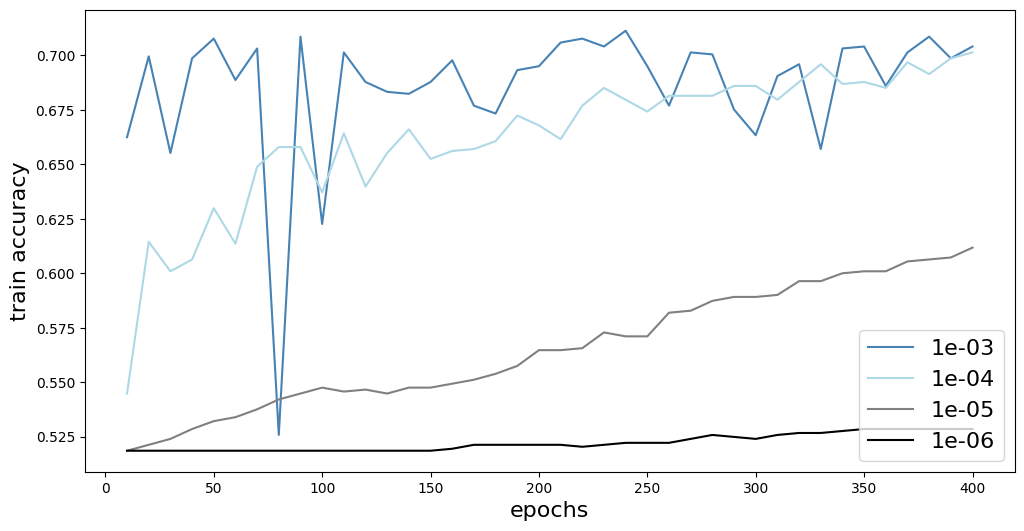

In [103]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
epochs_array = [i for i in range(store_epoch, epochs, store_epoch)]
epochs_array.append(epochs)
ax.plot(epochs_array, train_results[1e-3], color="steelblue", label='1e-03')
ax.plot(epochs_array, train_results[1e-4], color="lightblue", label='1e-04')
ax.plot(epochs_array, train_results[1e-5], color="grey", label='1e-05')
ax.plot(epochs_array, train_results[1e-6], color="black", label='1e-06')
ax.legend(loc="lower right", fontsize=16)
ax.set_xlabel("epochs", fontsize=16)
ax.set_ylabel("train accuracy", fontsize=16)
plt.show()

Plot testing results below.

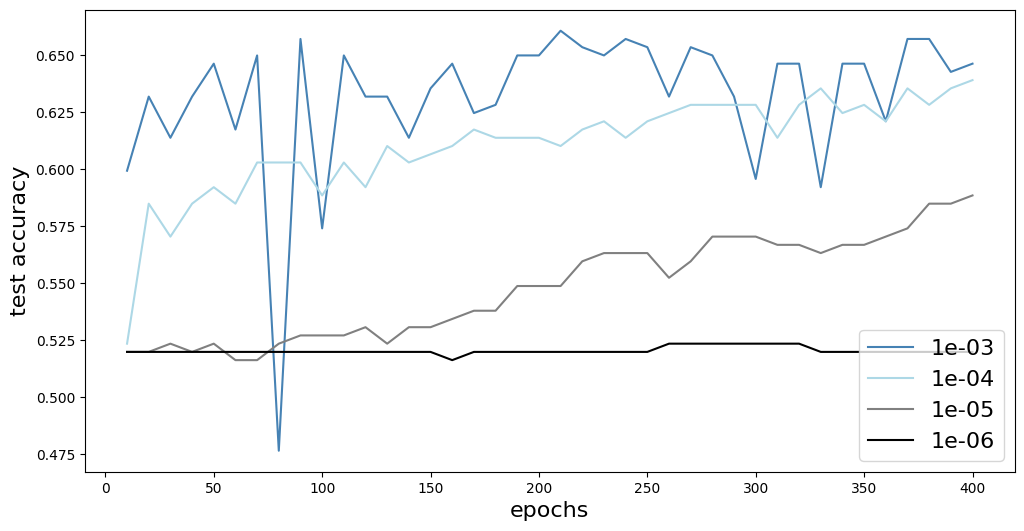

In [104]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
epochs_array = [i for i in range(store_epoch,epochs,store_epoch)]
epochs_array.append(epochs)
ax.plot(epochs_array, test_results[1e-3], color="steelblue", label='1e-03')
ax.plot(epochs_array, test_results[1e-4], color="lightblue", label='1e-04')
ax.plot(epochs_array, test_results[1e-5], color="grey", label='1e-05')
ax.plot(epochs_array, test_results[1e-6], color="black", label='1e-06')
ax.legend(loc="lower right", fontsize=16)
ax.set_xlabel("epochs", fontsize=16)
ax.set_ylabel("test accuracy", fontsize=16)
plt.show()

#### Part 2 D [15 points]

Adding $L_2$ regularization to the feature parameters for NLL loss gives:

$$
\textrm{NLL}_{L_2}(\boldsymbol{\mathbf w}) = -\displaystyle\sum_{i=1}^n \left[y_i \log \sigma(\boldsymbol{\mathbf w}^T{\bf x}_i) + (1-y_i)\log(1 - \sigma(\boldsymbol{\mathbf w}^T{\bf x}_i))\right] + \lambda\displaystyle\sum_{k=1}^{p} \mathbf w_{k}^2
$$

where $p$ is the number of features, and $\mathbf w_0$ is the bias term. Notice that $\mathbf w_0$ is not included in the regularization term.

Write down the derivative of the regularized negative log likelihood loss function $\textrm{NLL}_{L_2}$ with respect to $\boldsymbol{\mathbf w}$. Since we are working with SGD, derive it for $n=1$.

---
The derivative of the regularized negative log likelihood loss function $NLL_{L2}$ with respect to w with $n=1$ is:

$$
{\frac{NLL(w)}{\partial w}} = (\hat{y} - y) * x_{i} + 2*\lambda*w + w_{0}
$$

Being $\hat{y}$:

$$
\hat{y} =  \sigma(\boldsymbol{\mathbf w}^T{\bf x}_i)
$$

---


Update your implementation of the `sgd_update` method so that it performs regularized SGD updates of the model parameters to minimize the regularized NLL loss function.

Remember, do **not** regularize the bias parameter $\mathbf w_0$.

Provide train and test accuracy after above change with `lam=1e-5`.

In [105]:
from tests import tests
tests.run_test_suite('prob 2E', LogReg)

testNegRegUpdate (tests.tests.TestLogReg.testNegRegUpdate)
test update based on negative example ... ok
testPosRegUpdate (tests.tests.TestLogReg.testPosRegUpdate)
test regularized update based on positive example ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.002s

OK


#### Part 2 E [8 points]
Update your implementation of train() to incorporate a regularization term. The change should typically be on only one line in your code.

Plot accuracies of different values of $\lambda$ vs. epochs for both training and testing).

In [107]:
dataset_handler = Dataset('data/crime.csv')
train_results = {}
test_results = {}
epochs = 400
store_epoch = 10
eta = 1e-4
for lam in [0, 0.1, 0.05, 0.01]:

    train_acc, test_acc, _ = train(epochs, eta, store_epoch, lam)
    train_results[lam] = train_acc
    test_results[lam] = test_acc

Plot training results below.

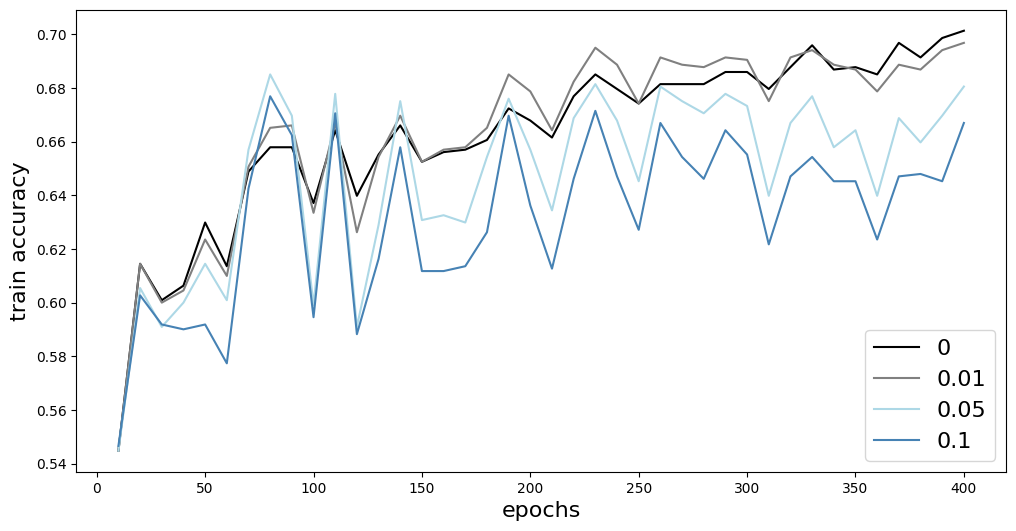

In [108]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
epochs_array = [i for i in range(store_epoch,epochs,store_epoch)]
epochs_array.append(epochs)
ax.plot(epochs_array, train_results[0], color="black", label=str(0))
ax.plot(epochs_array, train_results[0.01], color="grey", label=str(0.01))
ax.plot(epochs_array, train_results[0.05], color="lightblue", label=str(0.05))
ax.plot(epochs_array, train_results[0.1], color="steelblue", label=str(0.1))
ax.legend(loc="lower right", fontsize=16)
ax.set_xlabel("epochs", fontsize=16)
ax.set_ylabel("train accuracy", fontsize=16)
plt.show()

Plot testing results below.

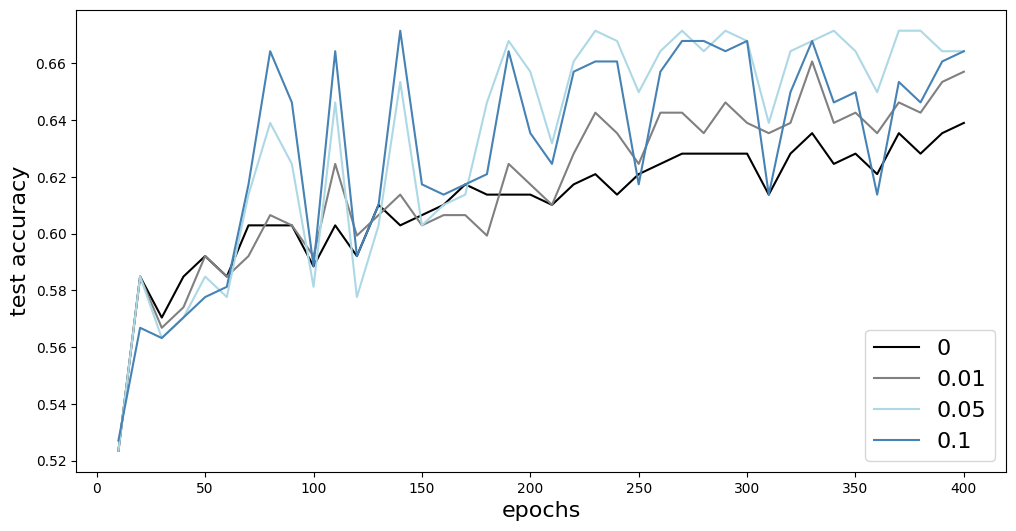

In [109]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
epochs_array = [i for i in range(store_epoch,epochs,store_epoch)]
epochs_array.append(epochs)
ax.plot(epochs_array, test_results[0], color="black", label=str(0))
ax.plot(epochs_array, test_results[0.01], color="grey", label=str(0.01))
ax.plot(epochs_array, test_results[0.05], color="lightblue", label=str(0.05))
ax.plot(epochs_array, test_results[0.1], color="steelblue", label=str(0.1))
ax.legend(loc="lower right", fontsize=16)
ax.set_xlabel("epochs", fontsize=16)
ax.set_ylabel("test accuracy", fontsize=16)
plt.show()

### Part 2 F [7 points] 
What is the effect of regularization term with respect to accuracy? 

---

We need to compare the accuracy with the regularization term with the one without the regularization term when eta = 1e-4.

In the one without the regularization term, the accuracy of the training and the test set grew dramatically after the first epochs and then the growing smooths after each epoch without any big peaks or lows.

Yet, when we include any different regularization term, we can observe that model comes inestable, and that the inestability is bigger when the regularization term is bigger.

About accuracy levels, we can observe that without the regularization, the accuracy went to ~70% in training and ~63% in testing after 400 epochs. Now, with the regularization term, the biggest training accuracy is also round ~70%, being more accurate with a smaller regularization term. For the training set, the minimun accuracy is ~64% (having an improvement over the model without the regularization), and we can observe that bigger regularization terms imply better accuracy. For the training set, bigger regularization term implies more unstable models but after 400 epochs, more accuracy (which may after 400 epochs drop because of its unstability).

---

### Part 3 [10 points] 

Time based Learning Rate is dynamic learning rate given the following equation:

$\textrm{LearningRate} = \eta\, / \,(1 + \textrm{decay} \cdot \textrm{current epoch})$

Train SGD with the dynamic learning rate defined above and follow these instructions:
* Use initial learning rate $\eta = 0.1$.
* Use $\textrm{decay} = 0.001$.
* Update learning rate `lr.eta` every epoch.
* Use $\lambda = 0$ (no regularization)
* Plot train accuracy and learning rate together for each epoch.

The above can be accomplished by changing one line in `train()` from Part 2a. 

In [110]:
eta  = 1e-1
epochs = 200
store_epoch = 1

# Lists required for plotting
train_accuracy_array = None
learning_rates = None

decay = 0.001
lam = 0

train_accuracy_array, test_accuracy_array, learning_rates = train(epochs, eta, store_epoch, lam, decay)


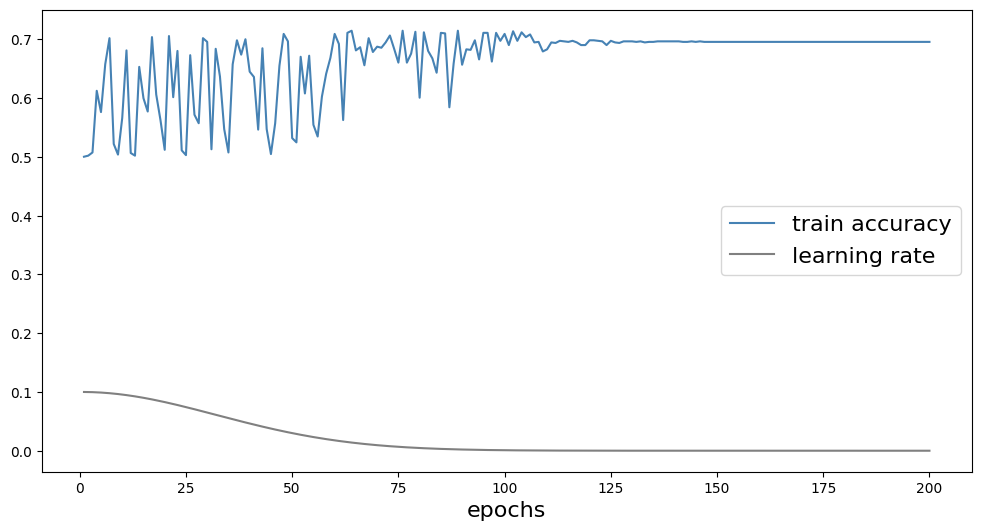

In [111]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
epochs_array = [i for i in range(1,epochs)]
epochs_array.append(epochs)
ax.plot(epochs_array, train_accuracy_array, color="steelblue", label=str('train accuracy'))
ax.plot(epochs_array, learning_rates,color="grey", label=str('learning rate'))
ax.legend(loc="center right", fontsize=16)
ax.set_xlabel("epochs", fontsize=16)
ax.set_ylabel("", fontsize=16)
plt.show()

### Optional survey.
***

We are interested in your feedback. At the end of each homework, there is a simple anonymous feedback [survey](https://docs.google.com/forms/d/e/1FAIpQLSdHs_zhF83WrT2v8AmU_KS73loWeGX1zSSYKPewmrQ9JnHhcg/viewform?usp=header) to solicit your feedback for how to improve the course.

Acknowledgment: Noah Smith, Chris Ketelsen, Chenhao Tan